# ĐÁNH GIÁ MÔ HÌNH BARTPHO — PRE-TRAINED vs FINE-TUNED

Notebook này thực hiện đánh giá toàn diện hai phiên bản mô hình:
- **Pre-trained**: `vinai/bartpho-word` — baseline zero-shot
- **Fine-tuned**: `hailinh1509/bartpho-news-summarizer` — model đã fine-tune trên dữ liệu tóm tắt tin tức tiếng Việt

Đánh giá gồm:
1. Tính ROUGE-1/2/L trên tập test
2. So sánh định lượng giữa hai model
3. Phân tích định tính qua ví dụ cụ thể
4. Phân tích phân phối độ dài output và lỗi thường gặp

## BƯỚC 1: THIẾT LẬP MÔI TRƯỜNG

In [ ]:
# Cài đặt thư viện nếu chạy trên Colab
!pip install transformers datasets evaluate sentencepiece rouge-score openpyxl accelerate -q

import os
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import evaluate
from tqdm.auto import tqdm

# Thiết lập font cho matplotlib để hiển thị tiếng Việt
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

# Xác định thiết bị (GPU hoặc CPU) để chạy mô hình
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Thiết bị: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.4 MB/s eta 0:00:00
Thiết bị: cuda
GPU: Tesla T4


In [ ]:
from google.colab import drive

# Gắn Google Drive để truy cập dữ liệu và lưu kết quả
drive.mount('/content/drive')

Mounted at /content/drive


## BƯỚC 2: TẢI DỮ LIỆU TEST

In [ ]:
# ID của file dữ liệu test trên Google Drive
file_id_test = "1ZbRhP2IT8xzq1UJsQTpIPxrpvHCHaD4O"
# Tạo đường dẫn tải xuống dữ liệu
test_path = f"https://drive.google.com/uc?export=download&id={file_id_test}"

print("Đang tải dữ liệu...")
# Đọc dữ liệu từ file Excel vào DataFrame
test_df = pd.read_excel(test_path)

print(f"Test       : {len(test_df):,} mẫu")
print(f"Cột        : {list(test_df.columns)}")

# Hiển thị 5 hàng đầu tiên của dữ liệu test
test_df.head(5)

Đang tải dữ liệu...
Test       : 936 mẫu
Cột        : ['content', 'summary']


,content,summary
0,Nhiều đại lý chính hãng của Yamaha đang bán mẫ...,Yamaha R15 2014 là mẫu xe côn tay thể thao cỡ ...
1,Tổng thống Mexico Enrique Penã Nieto trong cuộ...,Tổng thống Mexico Enrique Penã Nieto đã bắt đầ...
2,"Hôm 16/12, Ủy ban Kiểm tra trung ương yêu cầu ...",Ông Lê Phước Hoài Bảo (SN 1985) là con trai ng...
3,Tỷ lệ chọi cao nhất 1/8.\nNằm trong số những t...,"Năm 2011, các trường Đại học công nghiệp Hà Nộ..."
4,"Mỗi lần về quê, chị dâu đều trở thành đề tài b...",Tôi đã thất vọng tràn trề khi phát hiện ra sự ...


## BƯỚC 3: LOAD MÔ HÌNH

In [ ]:
# Định nghĩa checkpoint cho mô hình pre-trained và fine-tuned
PRETRAINED_CKPT = "vinai/bartpho-word"
FINETUNED_CKPT = "hailinh1509/bartpho-news-summarizer"

print(f"Pre-trained checkpoint : {PRETRAINED_CKPT}")
print(f"Fine-tuned checkpoint  : {FINETUNED_CKPT}")

Pre-trained checkpoint : vinai/bartpho-word
Fine-tuned checkpoint  : hailinh1509/bartpho-news-summarizer


In [ ]:
print("Đang load Pre-trained model...")
# Tải tokenizer và mô hình pre-trained
pretrained_tokenizer = AutoTokenizer.from_pretrained(PRETRAINED_CKPT, use_fast=False)
pretrained_model = AutoModelForSeq2SeqLM.from_pretrained(PRETRAINED_CKPT).to(device)
# Đặt mô hình ở chế độ đánh giá (evaluation mode)
pretrained_model.eval()
print("Load Pre-trained OK!")

Đang load Pre-trained model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/897 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.13M [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Load Pre-trained OK!


In [ ]:
print("Đang load Fine-tuned model...")
# Tải tokenizer và mô hình fine-tuned
finetuned_tokenizer = AutoTokenizer.from_pretrained(FINETUNED_CKPT, use_fast=False)
finetuned_model = AutoModelForSeq2SeqLM.from_pretrained(FINETUNED_CKPT).to(device)
# Đặt mô hình ở chế độ đánh giá (evaluation mode)
finetuned_model.eval()
print("Load Fine-tuned OK!")

Đang load Fine-tuned model...


config.json:   0%|          | 0.00/937 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/895k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.14M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/516 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/956 [00:00<?, ?B/s]

Load Fine-tuned OK!


## BƯỚC 4: HÀM SINH TÓM TẮT VÀ TÍNH ROUGE

In [ ]:
from rouge_score import rouge_scorer as _rouge_scorer

# Tham số cấu hình cho việc sinh tóm tắt (generation kwargs)
GENERATE_KWARGS = dict(
    max_new_tokens=256,       # Số token mới tối đa được sinh ra, không tính input — tránh cắt cụt
    max_length=None,          # Đặt None để tránh xung đột với max_new_tokens, ưu tiên max_new_tokens
    min_length=10,            # Đảm bảo output đủ dài
    num_beams=4,              # Sử dụng Beam Search với 4 beam để tìm kiếm tóm tắt tốt nhất
    no_repeat_ngram_size=3,   # Cấm lặp lại các 3-gram — giảm thiểu hiện tượng 'hallucination'
    length_penalty=1.0,       # Hệ số phạt độ dài, 1.0 là trung tính
    repetition_penalty=1.2,   # Hệ số phạt lặp lại token
    early_stopping=True       # Dừng sớm khi tất cả các beam đã hoàn thành
)

def compute_rouge_scores(predictions, references):
    """Tính toán các điểm ROUGE (ROUGE-1, ROUGE-2, ROUGE-L) từ danh sách dự đoán và tham chiếu."""
    scorer = _rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    r1_f, r1_p, r1_r = [], [], [] # ROUGE-1 F-measure, Precision, Recall
    r2_f, r2_p, r2_r = [], [], [] # ROUGE-2 F-measure, Precision, Recall
    rl_f, rl_p, rl_r = [], [], [] # ROUGE-L F-measure, Precision, Recall

    for pred, ref in zip(predictions, references):
        s = scorer.score(ref, pred)
        r1_f.append(s['rouge1'].fmeasure); r1_p.append(s['rouge1'].precision); r1_r.append(s['rouge1'].recall)
        r2_f.append(s['rouge2'].fmeasure); r2_p.append(s['rouge2'].precision); r2_r.append(s['rouge2'].recall)
        rl_f.append(s['rougeL'].fmeasure); rl_p.append(s['rougeL'].precision); rl_r.append(s['rougeL'].recall)

    return {
        'rouge1_fmeasure':  round(float(np.mean(r1_f)) * 100, 4),
        'rouge1_precision': round(float(np.mean(r1_p)) * 100, 4),
        'rouge1_recall':    round(float(np.mean(r1_r)) * 100, 4),
        'rouge2_fmeasure':  round(float(np.mean(r2_f)) * 100, 4),
        'rouge2_precision': round(float(np.mean(r2_p)) * 100, 4),
        'rouge2_recall':    round(float(np.mean(r2_r)) * 100, 4),
        'rougeL_fmeasure':  round(float(np.mean(rl_f)) * 100, 4),
        'rougeL_precision': round(float(np.mean(rl_p)) * 100, 4),
        'rougeL_recall':    round(float(np.mean(rl_r)) * 100, 4),
        # Danh sách điểm ROUGE-L F-measure cho từng mẫu (dùng cho phân tích per-sample)
        '_per_sample_rougeL_f': rl_f,
    }


def generate_summary(text, tokenizer, model, max_input_length=512):
    """Sinh tóm tắt cho một đoạn văn bản đầu vào sử dụng mô hình và tokenizer đã cho."""
    # Mã hóa văn bản đầu vào thành các tensor
    inputs = tokenizer(
        text,
        return_tensors="pt",
        max_length=max_input_length,
        truncation=True, # Cắt bớt nếu văn bản dài hơn max_input_length
        padding=True
    )
    # Chuyển các tensor đầu vào sang thiết bị của mô hình (GPU/CPU)
    inputs = {k: v.to(model.device) for k, v in inputs.items()}

    with torch.no_grad():
        # Sinh tóm tắt bằng mô hình
        output_ids = model.generate(**inputs, **GENERATE_KWARGS)

    # Giải mã các ID đầu ra thành văn bản tóm tắt
    return tokenizer.decode(output_ids[0], skip_special_tokens=True)


def evaluate_on_dataset(df, tokenizer, model, label="Model", sample_size=None):
    """Đánh giá hiệu suất của mô hình trên một tập dữ liệu cụ thể."""
    if sample_size is not None:
        # Lấy mẫu ngẫu nhiên nếu sample_size được chỉ định
        df = df.sample(n=sample_size, random_state=42).reset_index(drop=True)
        print(f"[{label}] Đánh giá trên {sample_size} mẫu (sampled)")
    else:
        print(f"[{label}] Đánh giá trên toàn bộ {len(df):,} mẫu")

    predictions = []
    references  = list(df["summary"].astype(str))

    # Lặp qua từng hàng của DataFrame để sinh tóm tắt
    for i, row in tqdm(df.iterrows(), total=len(df), desc=label):
        pred = generate_summary(str(row["content"]), tokenizer, model)
        predictions.append(pred)

    # Tính toán điểm ROUGE
    result = compute_rouge_scores(predictions, references)

    # In kết quả ROUGE ra màn hình
    print(f"  ROUGE-1 F1: {result['rouge1_fmeasure']}% (P: {result['rouge1_precision']}%, R: {result['rouge1_recall']}%) ")
    print(f"  ROUGE-2 F1: {result['rouge2_fmeasure']}% (P: {result['rouge2_precision']}%, R: {result['rouge2_recall']}%) ")
    print(f"  ROUGE-L F1: {result['rougeL_fmeasure']}% (P: {result['rougeL_precision']}%, R: {result['rougeL_recall']}%) ")

    return result, predictions


print("Hàm đánh giá đã sẵn sàng.")

Hàm đánh giá đã sẵn sàng.


## BƯỚC 5: ĐÁNH GIÁ TRÊN TẬP TEST

In [ ]:
print("="*60)
print("ĐÁNH GIÁ PRE-TRAINED trên Test (toàn bộ)")
print("="*60)
# Thực hiện đánh giá mô hình pre-trained trên toàn bộ tập test
pretrained_test_result, pretrained_test_preds = evaluate_on_dataset(
    test_df, pretrained_tokenizer, pretrained_model,
    label="Pre-trained (Test)", sample_size=None
)

ĐÁNH GIÁ PRE-TRAINED trên Test (toàn bộ)
[Pre-trained (Test)] Đánh giá trên toàn bộ 936 mẫu


Pre-trained (Test):   0%|          | 0/936 [00:00<?, ?it/s]

  ROUGE-1 F1: 64.297% (P: 51.3473%, R: 92.2283%) 
  ROUGE-2 F1: 47.5643% (P: 37.8869%, R: 68.625%) 
  ROUGE-L F1: 45.902% (P: 36.5139%, R: 66.5157%) 


In [ ]:
print("="*60)
print("ĐÁNH GIÁ FINE-TUNED trên Test (toàn bộ)")
print("="*60)
# Thực hiện đánh giá mô hình fine-tuned trên toàn bộ tập test
finetuned_test_result, finetuned_test_preds = evaluate_on_dataset(
    test_df, finetuned_tokenizer, finetuned_model,
    label="Fine-tuned (Test)", sample_size=None
)

ĐÁNH GIÁ FINE-TUNED trên Test (toàn bộ)
[Fine-tuned (Test)] Đánh giá trên toàn bộ 936 mẫu


Fine-tuned (Test):   0%|          | 0/936 [00:00<?, ?it/s]

  ROUGE-1 F1: 73.5287% (P: 72.9574%, R: 80.1245%) 
  ROUGE-2 F1: 52.947% (P: 52.5447%, R: 57.7596%) 
  ROUGE-L F1: 53.102% (P: 52.7092%, R: 58.051%) 


## BƯỚC 6: BẢNG SO SÁNH TỔNG HỢP

In [ ]:
# Tạo DataFrame để so sánh kết quả ROUGE của hai mô hình
comparison_df = pd.DataFrame([
    {
        "Mô hình": "Pre-trained (vinai/bartpho-word)",
        "Tập đánh giá": f"Test (n={len(test_df)})",
        "ROUGE-1 F1": pretrained_test_result["rouge1_fmeasure"],
        "ROUGE-1 P": pretrained_test_result["rouge1_precision"],
        "ROUGE-1 R": pretrained_test_result["rouge1_recall"],
        "ROUGE-2 F1": pretrained_test_result["rouge2_fmeasure"],
        "ROUGE-2 P": pretrained_test_result["rouge2_precision"],
        "ROUGE-2 R": pretrained_test_result["rouge2_recall"],
        "ROUGE-L F1": pretrained_test_result["rougeL_fmeasure"],
        "ROUGE-L P": pretrained_test_result["rougeL_precision"],
        "ROUGE-L R": pretrained_test_result["rougeL_recall"]
    },
    {
        "Mô hình": "Fine-tuned (hailinh1509/bartpho-news-summarizer)",
        "Tập đánh giá": f"Test (n={len(test_df)})",
        "ROUGE-1 F1": finetuned_test_result["rouge1_fmeasure"],
        "ROUGE-1 P": finetuned_test_result["rouge1_precision"],
        "ROUGE-1 R": finetuned_test_result["rouge1_recall"],
        "ROUGE-2 F1": finetuned_test_result["rouge2_fmeasure"],
        "ROUGE-2 P": finetuned_test_result["rouge2_precision"],
        "ROUGE-2 R": finetuned_test_result["rouge2_recall"],
        "ROUGE-L F1": finetuned_test_result["rougeL_fmeasure"],
        "ROUGE-L P": finetuned_test_result["rougeL_precision"],
        "ROUGE-L R": finetuned_test_result["rougeL_recall"]
    }
])

print("BẢNG SO SÁNH ROUGE — PRE-TRAINED vs FINE-TUNED")
display(comparison_df)

# Tính mức cải thiện tuyệt đối trên tập test
metrics = ["ROUGE-1 F1", "ROUGE-1 P", "ROUGE-1 R",
           "ROUGE-2 F1", "ROUGE-2 P", "ROUGE-2 R",
           "ROUGE-L F1", "ROUGE-L P", "ROUGE-L R"]

delta_rows = []
for m in metrics:
    pre = comparison_df[comparison_df["Mô hình"].str.startswith("Pre")][m].values[0]
    ft  = comparison_df[comparison_df["Mô hình"].str.startswith("Fine")][m].values[0]
    delta_rows.append({"Metric": m, "Pre-trained": pre, "Fine-tuned": ft, "Cải thiện (+)": round(ft - pre, 2)})

delta_df = pd.DataFrame(delta_rows)
print("\nMỨC CẢI THIỆN (Fine-tuned - Pre-trained) trên tập Test:")
display(delta_df)

BẢNG SO SÁNH ROUGE — PRE-TRAINED vs FINE-TUNED


,Mô hình,Tập đánh giá,ROUGE-1 F1,ROUGE-1 P,ROUGE-1 R,ROUGE-2 F1,ROUGE-2 P,ROUGE-2 R,ROUGE-L F1,ROUGE-L P,ROUGE-L R
0,Pre-trained (vinai/bartpho-word),Test (n=936),64.2970,51.3473,92.2283,47.5643,37.8869,68.6250,45.902,36.5139,66.5157
1,Fine-tuned (hailinh1509/bartpho-news-summarizer),Test (n=936),73.5287,72.9574,80.1245,52.9470,52.5447,57.7596,53.102,52.7092,58.0510



MỨC CẢI THIỆN (Fine-tuned - Pre-trained) trên tập Test:


,Metric,Pre-trained,Fine-tuned,Cải thiện (+)
0,ROUGE-1 F1,64.2970,73.5287,9.23
1,ROUGE-1 P,51.3473,72.9574,21.61
2,ROUGE-1 R,92.2283,80.1245,-12.10
3,ROUGE-2 F1,47.5643,52.9470,5.38
4,ROUGE-2 P,37.8869,52.5447,14.66
5,ROUGE-2 R,68.6250,57.7596,-10.87
6,ROUGE-L F1,45.9020,53.1020,7.20
7,ROUGE-L P,36.5139,52.7092,16.20
8,ROUGE-L R,66.5157,58.0510,-8.46


## BƯỚC 7: BIỂU ĐỒ SO SÁNH ROUGE

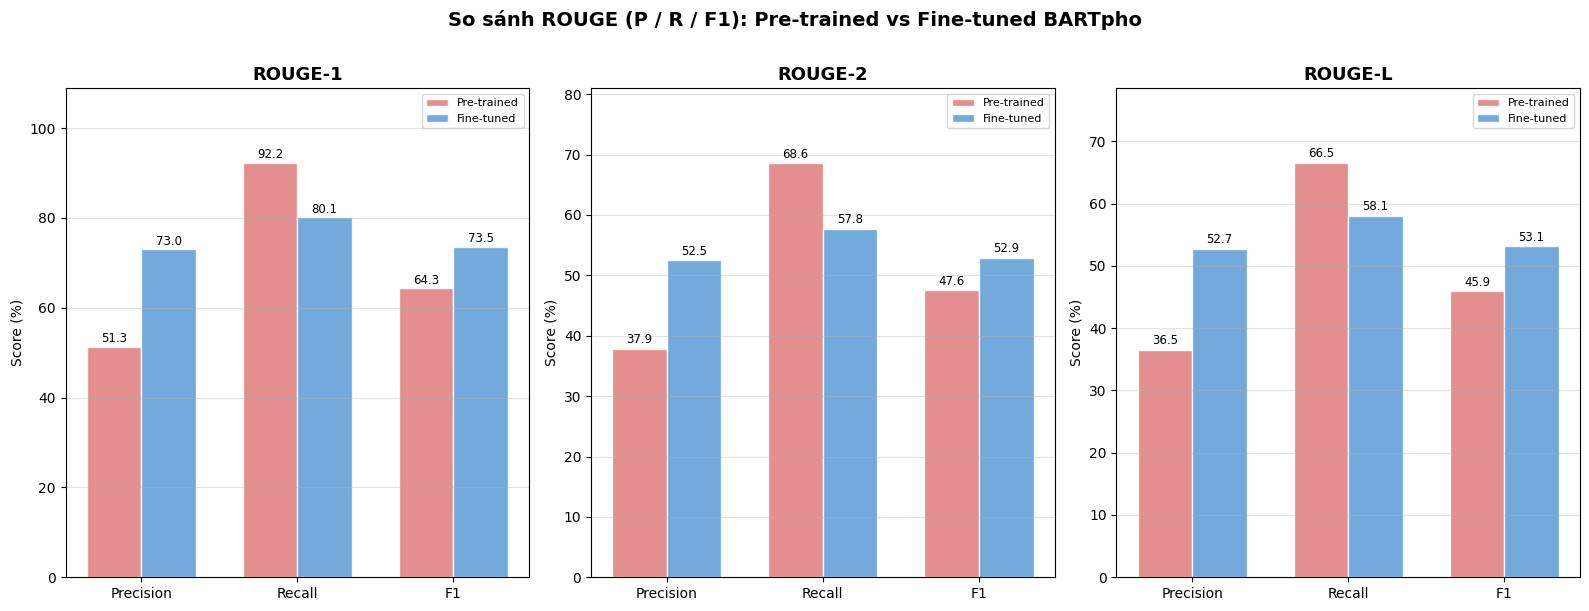

Đã lưu biểu đồ vào run/rouge_comparison.png


In [ ]:
# Lấy kết quả ROUGE cho từng mô hình từ các bước trước
result_pre = pretrained_test_result
result_ft = finetuned_test_result

# Khởi tạo figure và các subplot để vẽ 3 biểu đồ ROUGE
fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)

# Thông tin các chỉ số ROUGE để lặp qua
metrics_info = [
    ("ROUGE-1", "rouge1"),
    ("ROUGE-2", "rouge2"),
    ("ROUGE-L", "rougeL"),
]
sub_metrics  = ["precision", "recall", "fmeasure"]
sub_labels   = ["Precision", "Recall", "F1"]
x            = np.arange(len(sub_metrics)) # Vị trí các cột trên trục x
width        = 0.35 # Chiều rộng của mỗi cột
colors_pre   = "#e07b7b" # Màu cho mô hình Pre-trained
colors_ft    = "#5b9bd5"  # Màu cho mô hình Fine-tuned

# Lặp qua từng loại ROUGE (ROUGE-1, ROUGE-2, ROUGE-L)
for ax, (rouge_label, rouge_key) in zip(axes, metrics_info):
    # Lấy giá trị Precision, Recall, F1 cho mô hình Pre-trained và Fine-tuned
    pre_vals = [result_pre[f"{rouge_key}_{s}"] for s in ["precision", "recall", "fmeasure"]]
    ft_vals  = [result_ft [f"{rouge_key}_{s}"] for s in ["precision", "recall", "fmeasure"]]

    # Vẽ cột cho mô hình Pre-trained
    bars1 = ax.bar(x - width/2, pre_vals, width, label="Pre-trained",
                   color=colors_pre, alpha=0.85, edgecolor="white")
    # Vẽ cột cho mô hình Fine-tuned
    bars2 = ax.bar(x + width/2, ft_vals,  width, label="Fine-tuned",
                   color=colors_ft,  alpha=0.85, edgecolor="white")

    # Ghi giá trị số lên đầu mỗi cột
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8.5)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f"{bar.get_height():.1f}", ha="center", va="bottom", fontsize=8.5)

    ax.set_title(rouge_label, fontsize=13, fontweight="bold")
    ax.set_ylabel("Score (%)")
    ax.set_xticks(x)
    ax.set_xticklabels(sub_labels)
    ax.set_ylim(0, max(max(pre_vals), max(ft_vals)) * 1.18) # Điều chỉnh giới hạn trục y
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=0.35)

# Đặt tiêu đề chung cho tất cả các biểu đồ con
plt.suptitle("So sánh ROUGE (P / R / F1): Pre-trained vs Fine-tuned BARTpho",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout() # Tự động điều chỉnh khoảng cách giữa các subplot
# Lưu biểu đồ vào Google Drive
plt.savefig("/content/drive/MyDrive/run/rouge_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Đã lưu biểu đồ vào run/rouge_comparison.png")

## BƯỚC 8: PHÂN TÍCH PHÂN PHỐI ĐỘ DÀI OUTPUT

PHÂN PHỐI ĐỘ DÀI OUTPUT (số từ) trên tập Test:
                           Pre-trained   Fine-tuned    Reference
-----------------------------------------------------------------
  Min                             36.0         15.0          9.0
  Mean                           193.4        122.0        110.2
  Median                         203.0        118.0        107.0
  95th pct                       220.0        189.2        179.0
  Max                            236.0        227.0        235.0


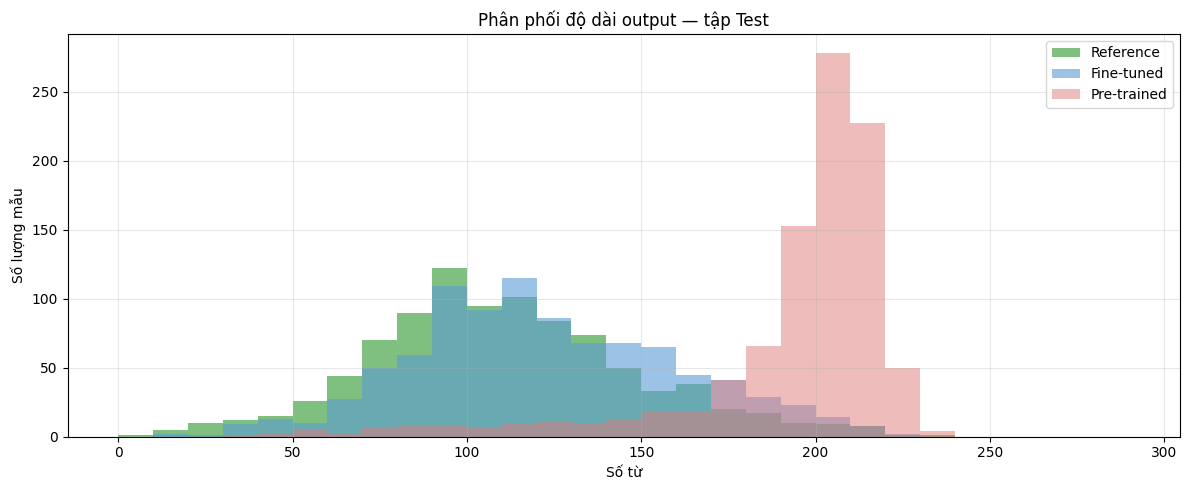

In [ ]:
# Tính độ dài (số từ) của các tóm tắt dự đoán và tham chiếu
pre_lens = [len(p.split()) for p in pretrained_test_preds] # Độ dài tóm tắt từ Pre-trained
ft_lens  = [len(p.split()) for p in finetuned_test_preds]  # Độ dài tóm tắt từ Fine-tuned
ref_lens = [len(str(r).split()) for r in test_df["summary"]] # Độ dài tóm tắt tham chiếu

print("PHÂN PHỐI ĐỘ DÀI OUTPUT (số từ) trên tập Test:")
print(f"{'':25s} {'Pre-trained':>12s} {'Fine-tuned':>12s} {'Reference':>12s}")
print("-" * 65)
# Tính toán và in ra các thống kê về độ dài (min, mean, median, 95th percentile, max)
stats = [
    ("Min",    np.min),
    ("Mean",   np.mean),
    ("Median", np.median),
    ("95th pct", lambda x: np.percentile(x, 95)),
    ("Max",    np.max),
]
for name, fn in stats:
    print(f"  {name:23s} {fn(pre_lens):>12.1f} {fn(ft_lens):>12.1f} {fn(ref_lens):>12.1f}")

# Vẽ biểu đồ histogram phân phối độ dài
fig, ax = plt.subplots(figsize=(12, 5))
bins = range(0, 300, 10) # Các bin cho histogram
ax.hist(ref_lens, bins=bins, alpha=0.5, label="Reference",   color="green")
ax.hist(ft_lens,  bins=bins, alpha=0.6, label="Fine-tuned",  color="#5b9bd5")
ax.hist(pre_lens, bins=bins, alpha=0.5, label="Pre-trained", color="#e07b7b")
ax.set_xlabel("Số từ")
ax.set_ylabel("Số lượng mẫu")
ax.set_title("Phân phối độ dài output — tập Test")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
# Lưu biểu đồ vào Google Drive
plt.savefig("/content/drive/MyDrive/run/gen_len_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## BƯỚC 9: ĐÁNH GIÁ ĐỊNH TÍNH — VÍ DỤ CỤ THỂ

In [ ]:
def show_qualitative(df, pretrained_preds, finetuned_preds, indices=None, n=5):
    """Hiển thị so sánh output của hai model trên một số mẫu cụ thể."""
    # Nếu indices không được cung cấp, hiển thị n mẫu đầu tiên
    if indices is None:
        indices = list(range(n))

    # Lặp qua các chỉ số được chọn và hiển thị thông tin chi tiết
    for i in indices:
        row = df.iloc[i]
        print("="*80)
        print(f"MẪU #{i}")
        print("-"*80)
        print("NỘI DUNG BÀI BÁO (500 ký tự đầu):")
        print(str(row['content'])[:500] + "...")
        print("-"*80)
        print("REFERENCE (Tóm tắt chuẩn):")
        print(str(row['summary']))
        print("-"*40)
        print("PRE-TRAINED output:")
        print(pretrained_preds[i])
        print("-"*40)
        print("FINE-TUNED output:")
        print(finetuned_preds[i])
        print()

# Hiển thị 3 mẫu đầu tiên từ tập test để phân tích định tính
show_qualitative(test_df, pretrained_test_preds, finetuned_test_preds, n=3)

MẪU #0
--------------------------------------------------------------------------------
NỘI DUNG BÀI BÁO (500 ký tự đầu):
Nhiều đại lý chính hãng của Yamaha đang bán mẫu sportbike R15 2014 với 4 màu đồng-đen, xanh-trắng, đỏ-trắng và đen-trắng. Phiên bản màu đồng-đen nổi bật với bộ vành và tem xe trùng màu khá bắt mắt. So với các phiên bản khác, model này được bán đắt hơn 2 triệu đồng.
Yamaha hiện là hãng quan tâm nhiều nhất đến phân khúc xe côn tay thể thao cỡ nhỏ. Ngoài R15, nhiều đại lý của hãng còn bán cả FZ150i và FZ-S.
Chiếc R15 2014 có tem xe màu vàng đồng dán decal cách điệu ở hai bên yếm xe.
Bộ vành trước s...
--------------------------------------------------------------------------------
REFERENCE (Tóm tắt chuẩn):
Yamaha R15 2014 là mẫu xe côn tay thể thao cỡ nhỏ được bán tại thị trường Ấn Độ. Nó có 4 màu đồng-đen, xanh-trắng, đỏ-trắng và đen-trắng, trong đó phiên bản đồng-đen được bán đắt hơn 2 triệu đồng. Xe sử dụng động cơ 4 thì, 150cc, sản sinh công suất tối đa 18 mã lực 

## BƯỚC 10: LƯU KẾT QUẢ

In [ ]:
# Lưu bảng so sánh ROUGE vào file Excel trên Google Drive
comparison_df.to_excel("/content/drive/MyDrive/run/rouge_comparison.xlsx", index=False)
print("Đã lưu bảng ROUGE vào scratch/rouge_comparison.xlsx")

# Chuẩn bị DataFrame chứa nội dung, tóm tắt chuẩn, và các tóm tắt dự đoán
result_df = test_df[["content", "summary"]].copy()
result_df["pretrained_pred"] = pretrained_test_preds
result_df["finetuned_pred"]  = finetuned_test_preds
# Lưu prediction vào file Excel trên Google Drive
result_df.to_excel("/content/drive/MyDrive/run/test_predictions.xlsx", index=False)
print("Đã lưu prediction vào scratch/test_predictions.xlsx")

# In tóm tắt cuối cùng
print("\n" + "="*140)
print("KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST")
print("="*140)
display(comparison_df)

Đã lưu bảng ROUGE vào scratch/rouge_comparison.xlsx
Đã lưu prediction vào scratch/test_predictions.xlsx

KẾT QUẢ CUỐI CÙNG TRÊN TẬP TEST


,Mô hình,Tập đánh giá,ROUGE-1 F1,ROUGE-1 P,ROUGE-1 R,ROUGE-2 F1,ROUGE-2 P,ROUGE-2 R,ROUGE-L F1,ROUGE-L P,ROUGE-L R
0,Pre-trained (vinai/bartpho-word),Test (n=936),64.2970,51.3473,92.2283,47.5643,37.8869,68.6250,45.902,36.5139,66.5157
1,Fine-tuned (hailinh1509/bartpho-news-summarizer),Test (n=936),73.5287,72.9574,80.1245,52.9470,52.5447,57.7596,53.102,52.7092,58.0510
